# Battery power prediction from real-driving telemetry

This notebook develops a data-driven model for estimating the instantaneous battery power of an electric vehicle from real-driving telemetry. The measurements come from multiple BMW i3 trips and include vehicle dynamics, battery state, environmental conditions and auxiliary loads.

The target is computed from battery voltage and current as

$$P_{batt}(t)=-\frac{V_{batt}(t)I_{batt}(t)}{1000}$$

where positive power represents battery discharge and negative power represents regenerative braking. A sequence-to-sequence LSTM predicts one power value for every sample in the input window.

## Methodology

### Data preparation

The workflow cleans column names, corrects the malformed velocity header in TripB38, derives instantaneous battery power, combines measured and displayed SOC, and estimates road gradient from elevation and travelled distance. Non-finite values are converted to missing values and removed only from the variables required by the model.

### Experimental split

Only Category B trips are used because their measurements are more consistent. Complete trips are assigned to training, validation and test subsets (26/6/6). Splitting by trip prevents temporal leakage: windows from one journey cannot appear in more than one subset.

### Input and target

The input includes vehicle speed, throttle, motor torque, longitudinal acceleration, regenerative-braking state, road gradient, SOC, battery and ambient temperatures, heating power and air-conditioning power. Battery voltage and current are excluded from the inputs because they directly define the target and would introduce data leakage.

### Scaling and temporal formulation

Input features are standardized using statistics fitted exclusively on the training set. The target is not normalized and therefore remains in kW. Each input window has shape [sequence length, number of features], while its target has shape [sequence length, 1]. This sequence-to-sequence formulation produces one power estimate per time sample.

### Model and training

The model uses a two-layer LSTM followed by dropout and a fully connected regression head with GELU activation. The final layer is linear so that predictions can represent both positive discharge power and negative regenerative power. Training uses Smooth L1 loss, Adam optimization, gradient clipping and early stopping based on validation loss.

### Evaluation

Predictions are evaluated on trips that are completely unseen during training. MAE measures the average error in kW, RMSE emphasizes large errors and missed peaks, and R² measures explained variance. MAPE is calculated only for samples with absolute real power of at least 1 kW because percentage error is unstable around zero. The final plot compares measured and predicted power over the complete test output. If temporal windows overlap, repeated samples must be considered when interpreting global metrics and the flattened plot.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
main_dir = '/kaggle/input/datasets/atechnohazard/battery-and-heating-data-in-real-driving-cycles/'

In [3]:
TripA01 = pd.read_csv(
    main_dir + 'TripA01.csv',
    encoding="latin1",
    sep=";"
)

TripA01.head()

,Time [s],Velocity [km/h],Elevation [m],Throttle [%],Motor Torque [Nm],Longitudinal Acceleration [m/s^2],Regenerative Braking Signal,Battery Voltage [V],Battery Current [A],Battery Temperature [°C],...,AirCon Power [kW],Heater Signal,Heater Voltage [V],Heater Current [A],Ambient Temperature [°C],Coolant Temperature Heatercore [°C],Requested Coolant Temperature [°C],Coolant Temperature Inlet [°C],Heat Exchanger Temperature [°C],Cabin Temperature Sensor [°C]
0,0.0,0.0,574.0,0.0,0.0,-0.03,0.0,391.4,-2.20,21.0,...,0.4,1,0,0,25.5,0,0,0,30.5,24.5
1,0.1,0.0,574.0,0.0,0.0,0.00,0.0,391.4,-2.21,21.0,...,0.4,1,0,0,25.5,0,0,0,30.5,24.5
2,0.2,0.0,574.0,0.0,0.0,-0.01,0.0,391.4,-2.26,21.0,...,0.4,1,0,0,25.5,0,0,0,30.5,24.5
3,0.3,0.0,574.0,0.0,0.0,-0.03,0.0,391.4,-2.30,21.0,...,0.4,1,0,0,25.5,0,0,0,30.5,24.5
4,0.4,0.0,574.0,0.0,0.0,-0.03,0.0,391.4,-2.30,21.0,...,0.4,1,0,0,25.5,0,0,0,30.5,24.5


In [4]:
print("Dataset shape:", TripA01.shape)
print("\nData types:")
print(TripA01.dtypes)

Dataset shape: (10090, 28)

Data types:
Time [s]                               float64
Velocity [km/h]                        float64
Elevation [m]                          float64
Throttle [%]                           float64
Motor Torque [Nm]                      float64
Longitudinal Acceleration [m/s^2]      float64
Regenerative Braking Signal            float64
Battery Voltage [V]                    float64
Battery Current [A]                    float64
Battery Temperature [°C]               float64
max. Battery Temperature [°C]          float64
SoC [%]                                float64
displayed SoC [%]                      float64
min. SoC [%]                             int64
max. SoC [%)                             int64
Heating Power CAN [kW]                 float64
Heating Power LIN [W]                    int64
Requested Heating Power [W]              int64
AirCon Power [kW]                      float64
Heater Signal                            int64
Heater Voltage [V]  

In [5]:
TripA01["Battery Power [kW]"] = -(
    TripA01["Battery Voltage [V]"]
    * TripA01["Battery Current [A]"]
) / 1000

In [6]:
TripA01.isna().sum()

Time [s]                               0
Velocity [km/h]                        0
Elevation [m]                          0
Throttle [%]                           0
Motor Torque [Nm]                      0
Longitudinal Acceleration [m/s^2]      0
Regenerative Braking Signal            0
Battery Voltage [V]                    0
Battery Current [A]                    0
Battery Temperature [°C]               0
max. Battery Temperature [°C]          0
SoC [%]                                0
displayed SoC [%]                      0
min. SoC [%]                           0
max. SoC [%)                           0
Heating Power CAN [kW]                 0
Heating Power LIN [W]                  0
Requested Heating Power [W]            0
AirCon Power [kW]                      0
Heater Signal                          0
Heater Voltage [V]                     0
Heater Current [A]                     0
Ambient Temperature [°C]               0
Coolant Temperature Heatercore [°C]    0
Requested Coolan

In [7]:
for column in TripA01.columns:
    print(repr(column))

'Time [s]'
'Velocity [km/h]'
'Elevation [m]'
'Throttle [%]'
'Motor Torque [Nm]'
'Longitudinal Acceleration [m/s^2]'
'Regenerative Braking Signal '
'Battery Voltage [V]'
'Battery Current [A]'
'Battery Temperature [°C]'
'max. Battery Temperature [°C]'
'SoC [%]'
'displayed SoC [%]'
'min. SoC [%]'
'max. SoC [%)'
'Heating Power CAN [kW]'
'Heating Power LIN [W]'
'Requested Heating Power [W]'
'AirCon Power [kW]'
'Heater Signal'
'Heater Voltage [V]'
'Heater Current [A]'
'Ambient Temperature [°C]'
'Coolant Temperature Heatercore [°C]'
'Requested Coolant Temperature [°C]'
'Coolant Temperature Inlet [°C]'
'Heat Exchanger Temperature [°C]'
'Cabin Temperature Sensor [°C]'
'Battery Power [kW]'


In [8]:
TripA01.columns = TripA01.columns.str.strip()

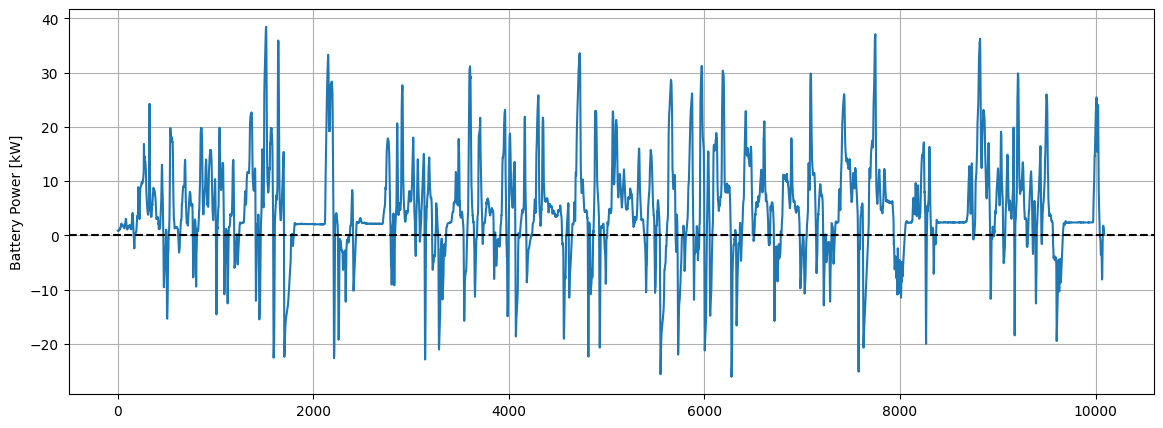

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(TripA01["Battery Power [kW]"])
plt.axhline(0, color="black", linestyle="--")
plt.ylabel("Battery Power [kW]")
plt.grid()
plt.show()

In [10]:
features = [
    "Velocity [km/h]",
    "Throttle [%]",
    "Motor Torque [Nm]",
    "Longitudinal Acceleration [m/s^2]",
    "Regenerative Braking Signal",
    "SoC [%]",
    "Battery Temperature [°C]",
    "Ambient Temperature [°C]",
    "Heating Power CAN [kW]",
    "AirCon Power [kW]"
]

target = "Battery Power [kW]"

In [11]:
velocity_ms = TripA01["Velocity [km/h]"] / 3.6
dt = TripA01["Time [s]"].diff()

TripA01["Distance Step [m]"] = velocity_ms * dt
TripA01["Elevation Step [m]"] = TripA01["Elevation [m]"].diff()

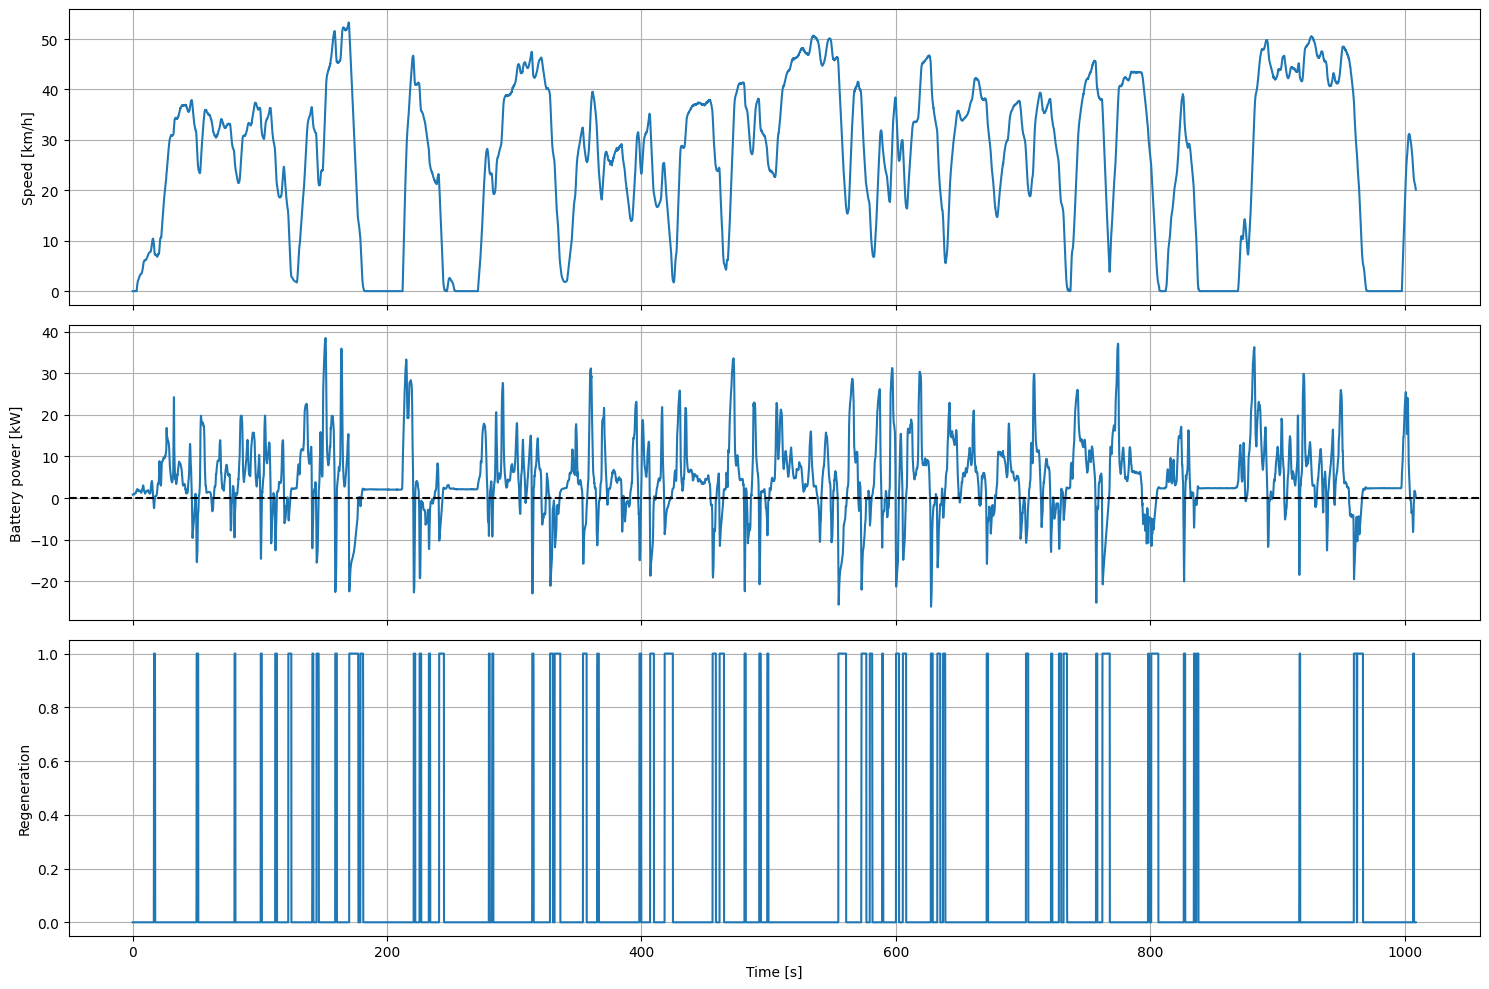

In [12]:
fig, axes = plt.subplots(
    3, 1,
    figsize=(15, 10),
    sharex=True
)

axes[0].plot(
    TripA01["Time [s]"],
    TripA01["Velocity [km/h]"]
)
axes[0].set_ylabel("Speed [km/h]")
axes[0].grid()

axes[1].plot(
    TripA01["Time [s]"],
    TripA01[target]
)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_ylabel("Battery power [kW]")
axes[1].grid()

axes[2].plot(
    TripA01["Time [s]"],
    TripA01["Regenerative Braking Signal"]
)
axes[2].set_ylabel("Regeneration")
axes[2].set_xlabel("Time [s]")
axes[2].grid()

plt.tight_layout()
plt.show()

In [13]:
import os

file_names = sorted([
    filename
    for filename in os.listdir(main_dir)
    if filename.lower().endswith(".csv")
])

file_names

['TripA01.csv',
 'TripA02.csv',
 'TripA03.csv',
 'TripA04.csv',
 'TripA05.csv',
 'TripA06.csv',
 'TripA07.csv',
 'TripA08.csv',
 'TripA09.csv',
 'TripA10.csv',
 'TripA11.csv',
 'TripA12.csv',
 'TripA13.csv',
 'TripA14.csv',
 'TripA15.csv',
 'TripA16.csv',
 'TripA17.csv',
 'TripA18.csv',
 'TripA19.csv',
 'TripA20.csv',
 'TripA21.csv',
 'TripA22.csv',
 'TripA23.csv',
 'TripA24.csv',
 'TripA25.csv',
 'TripA26.csv',
 'TripA27.csv',
 'TripA28.csv',
 'TripA29.csv',
 'TripA30.csv',
 'TripA31.csv',
 'TripA32.csv',
 'TripB01.csv',
 'TripB02.csv',
 'TripB03.csv',
 'TripB04.csv',
 'TripB05.csv',
 'TripB06.csv',
 'TripB07.csv',
 'TripB08.csv',
 'TripB09.csv',
 'TripB10.csv',
 'TripB11.csv',
 'TripB12.csv',
 'TripB13.csv',
 'TripB14.csv',
 'TripB15.csv',
 'TripB16.csv',
 'TripB17.csv',
 'TripB18.csv',
 'TripB19.csv',
 'TripB20.csv',
 'TripB21.csv',
 'TripB22.csv',
 'TripB23.csv',
 'TripB24.csv',
 'TripB25.csv',
 'TripB26.csv',
 'TripB27.csv',
 'TripB28.csv',
 'TripB29.csv',
 'TripB30.csv',
 'TripB3

In [14]:
from sklearn.model_selection import train_test_split

trip_b_names = sorted([
    filename
    for filename in file_names
    if filename.startswith("TripB")
])

# 26 training, 12 temporaneamente separati
train_files, temporary_files = train_test_split(
    trip_b_names,
    test_size=12,
    random_state=42,
    shuffle=True
)

# 6 validation e 6 test
validation_files, test_files = train_test_split(
    temporary_files,
    test_size=6,
    random_state=42,
    shuffle=True
)

train_files = sorted(train_files)
validation_files = sorted(validation_files)
test_files = sorted(test_files)

print("Training:", len(train_files), train_files)
print("Validation:", len(validation_files), validation_files)
print("Test:", len(test_files), test_files)

Training: 26 ['TripB01.csv', 'TripB02.csv', 'TripB03.csv', 'TripB04.csv', 'TripB06.csv', 'TripB08.csv', 'TripB10.csv', 'TripB11.csv', 'TripB12.csv', 'TripB13.csv', 'TripB15.csv', 'TripB17.csv', 'TripB19.csv', 'TripB20.csv', 'TripB21.csv', 'TripB22.csv', 'TripB23.csv', 'TripB24.csv', 'TripB26.csv', 'TripB29.csv', 'TripB30.csv', 'TripB32.csv', 'TripB33.csv', 'TripB35.csv', 'TripB36.csv', 'TripB38.csv']
Validation: 6 ['TripB07.csv', 'TripB09.csv', 'TripB14.csv', 'TripB28.csv', 'TripB31.csv', 'TripB37.csv']
Test: 6 ['TripB05.csv', 'TripB16.csv', 'TripB18.csv', 'TripB25.csv', 'TripB27.csv', 'TripB34.csv']


In [15]:
import os
import numpy as np
import pandas as pd


def load_battery_file(
    file_path,
    features=None,
    target="Battery Power [kW]"
):

    # ==========================
    # LETTURA
    # ==========================
    trip = pd.read_csv(
        file_path,
        encoding="latin1",
        sep=";"
    )

    # Pulizia intestazioni
    trip.columns = (
        trip.columns
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

    # Correzione TripB38
    trip = trip.rename(
        columns={
            "Velocity [km/h]]]":
            "Velocity [km/h]"
        }
    )


    # ==========================
    # TARGET: POTENZA BATTERIA
    # ==========================
    trip["Battery Power [kW]"] = -(
        trip["Battery Voltage [V]"]
        * trip["Battery Current [A]"]
    ) / 1000


    # ==========================
    # PULIZIA FINALE
    # ==========================
    trip = trip.replace(
        [np.inf, -np.inf],
        np.nan
    )

    # Elimina tutte le righe che contengono almeno un NaN
    trip = trip.dropna()

    trip = trip.reset_index(drop=True)

    return trip

In [16]:
train_dfs = [
    load_battery_file(
        os.path.join(main_dir, filename)
    )
    for filename in train_files
]

validation_dfs = [
    load_battery_file(
        os.path.join(main_dir, filename)
    )
    for filename in validation_files
]

test_dfs = [
    load_battery_file(
        os.path.join(main_dir, filename)
    )
    for filename in test_files
]

In [17]:
df_train = pd.concat(
    train_dfs,
    ignore_index=True
)

df_validation = pd.concat(
    validation_dfs,
    ignore_index=True
)

df_test = pd.concat(
    test_dfs,
    ignore_index=True
)

In [18]:
print(
    "NaN df_train:",
    df_train.isna().sum().sum()
)

print(
    "NaN df_validation:",
    df_validation.isna().sum().sum()
)

print(
    "NaN df_test:",
    df_test.isna().sum().sum()
)

NaN df_train: 0
NaN df_validation: 0
NaN df_test: 0


In [19]:
# Training
X_train = df_train[
    features
].to_numpy(dtype=np.float32)

y_train = df_train[
    target
].to_numpy(dtype=np.float32)


# Validation
X_validation = df_validation[
    features
].to_numpy(dtype=np.float32)

y_validation = df_validation[
    target
].to_numpy(dtype=np.float32)


# Test
X_test = df_test[
    features
].to_numpy(dtype=np.float32)

y_test = df_test[
    target
].to_numpy(dtype=np.float32)


print('Train Features shape: ',X_train.shape)
print('Train target shape: ',y_train.shape)

print('Validation Features shape: ',X_validation.shape)
print('Validation target shape: ',y_validation.shape)

print('Test Features shape: ',X_test.shape)
print('Test target shape: ',y_test.shape)

Train Features shape:  (388281, 10)
Train target shape:  (388281,)
Validation Features shape:  (129680, 10)
Validation target shape:  (129680,)
Test Features shape:  (54217, 10)
Test target shape:  (54217,)


In [20]:
print("Contiene NaN:", np.isnan(X_train).any())
print("Numero di NaN:", np.isnan(X_train).sum())

Contiene NaN: False
Numero di NaN: 0


In [21]:
from sklearn.preprocessing import StandardScaler

x_scaler = StandardScaler()

x_train = x_scaler.fit_transform(X_train)
x_valid = x_scaler.transform(X_validation)
x_test = x_scaler.transform(X_test)

In [22]:
print('Train Features shape: ',X_train.shape)
print('Train target shape: ',y_train.shape)

print('Validation Features shape: ',x_valid.shape)
print('Validation target shape: ',y_validation.shape)

print('Test Features shape: ',x_test.shape)
print('Test target shape: ',y_test.shape)

Train Features shape:  (388281, 10)
Train target shape:  (388281,)
Validation Features shape:  (129680, 10)
Validation target shape:  (129680,)
Test Features shape:  (54217, 10)
Test target shape:  (54217,)


In [23]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


class TimeSeriesDataset(Dataset):

    def __init__(
        self,
        features,
        targets,
        window_size=1000,
        stride=1000
    ):
        features = np.asarray(
            features,
            dtype=np.float32
        )

        targets = np.asarray(
            targets,
            dtype=np.float32
        )

        # Features: (samples, features)
        if features.ndim == 1:
            features = features.reshape(-1, 1)

        # Target: (samples, 1)
        if targets.ndim == 1:
            targets = targets.reshape(-1, 1)

        if len(features) != len(targets):
            raise ValueError(
                "Features e target devono avere "
                "lo stesso numero di campioni."
            )

        if window_size > len(features):
            raise ValueError(
                f"window_size={window_size} è maggiore "
                f"della serie, lunga {len(features)}."
            )

        self.features = torch.as_tensor(
            features,
            dtype=torch.float32
        )

        self.targets = torch.as_tensor(
            targets,
            dtype=torch.float32
        )

        self.window_size = window_size
        self.stride = stride

        self.num_windows = (
            len(self.features) - self.window_size
        ) // self.stride + 1

    def __len__(self):

        return self.num_windows

    def __getitem__(self, index):

        start = index * self.stride
        end = start + self.window_size

        # Forma: (window_size, numero_features)
        x_window = self.features[start:end]

        # Forma: (window_size, 1)
        y_window = self.targets[start:end]

        return x_window, y_window

In [24]:
window_size = 1000
stride = 1000


train_dataset = TimeSeriesDataset(
    features=x_train,
    targets=y_train,
    window_size=window_size,
    stride=stride
)


validation_dataset = TimeSeriesDataset(
    features=x_valid,
    targets=y_validation,
    window_size=window_size,
    stride=stride
)


test_dataset = TimeSeriesDataset(
    features=x_test,
    targets=y_test,
    window_size=window_size,
    stride=stride
)

In [25]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False
)

In [26]:
(
    x_batch,
    y_batch,
) = next(iter(train_loader))

print("x_batch:", x_batch.shape)
print("y_batch:", y_batch.shape)

x_batch: torch.Size([32, 1000, 10])
y_batch: torch.Size([32, 1000, 1])


In [27]:
import torch
import torch.nn as nn


class EnergyLSTM(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=2,
        dropout_p=0.1
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_p if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout_p)

        self.fc1 = nn.Linear(
            hidden_size,
            32
        )

        self.activation = nn.GELU()

        self.fc2 = nn.Linear(
            32,
            1
        )

    def forward(self, x):

        # x:
        # [batch, sequence_length, input_size]

        lstm_output, _ = self.lstm(x)

        # lstm_output:
        # [batch, sequence_length, hidden_size]

        x = self.dropout(lstm_output)

        # Linear applicato a ogni istante
        x = self.fc1(x)

        x = self.activation(x)

        x = self.fc2(x)

        # Output:
        # [batch, sequence_length, 1]

        return x

In [28]:
import torch
import torch.nn as nn

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

model = EnergyLSTM(
    input_size=len(features),
    hidden_size=64,
    num_layers=2,
    dropout_p=0.1
).to(device)

criterion = nn.SmoothL1Loss(
    beta=0.5
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

print(model)

Device: cpu
EnergyLSTM(
  (lstm): LSTM(10, 64, num_layers=2, batch_first=True, dropout=0.1)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (activation): GELU(approximate='none')
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


In [29]:
print(f"{'='*30}\nInitialized Model Architecture\n{'='*30}\n{model}")
print(f"\n{'='*30}\nOptimizer\n{'='*30}\n{optimizer}")
print(f"\n{'='*30}\nLoss Function\n{'='*30}\n{criterion}")

Initialized Model Architecture
EnergyLSTM(
  (lstm): LSTM(10, 64, num_layers=2, batch_first=True, dropout=0.1)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (activation): GELU(approximate='none')
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

Optimizer
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-05
)

Loss Function
SmoothL1Loss()


In [30]:
import copy
import torch

num_epochs = 50

train_losses = []
validation_losses = []

best_validation_loss = float("inf")
best_model_state = None

patience = 7
patience_counter = 0


for epoch in range(num_epochs):

    # ==========================
    # TRAINING
    # ==========================
    model.train()

    train_loss_sum = 0.0
    train_samples = 0

    for x_batch, y_batch in train_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        # [batch, sequence_length, 1]
        predictions = model(x_batch)

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()

        # Utile per stabilizzare la LSTM
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        batch_size = x_batch.size(0)

        train_loss_sum += (
            loss.item() * batch_size
        )

        train_samples += batch_size

    train_loss = (
        train_loss_sum / train_samples
    )


    # ==========================
    # VALIDATION
    # ==========================
    model.eval()

    validation_loss_sum = 0.0
    validation_samples = 0

    with torch.no_grad():

        for x_batch, y_batch in validation_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(x_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            batch_size = x_batch.size(0)

            validation_loss_sum += (
                loss.item() * batch_size
            )

            validation_samples += batch_size

    validation_loss = (
        validation_loss_sum
        / validation_samples
    )


    # ==========================
    # HISTORY
    # ==========================
    train_losses.append(train_loss)
    validation_losses.append(
        validation_loss
    )


    # ==========================
    # EARLY STOPPING
    # ==========================
    if validation_loss < best_validation_loss:

        best_validation_loss = validation_loss

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        patience_counter = 0

    else:

        patience_counter += 1


    print(
        f"Epoch [{epoch + 1:02d}/{num_epochs}] | "
        f"Train: {train_loss:.6f} | "
        f"Validation: {validation_loss:.6f} | "
        f"Patience: {patience_counter}/{patience}"
    )


    if patience_counter >= patience:

        print(
            f"\nEarly stopping all'epoca "
            f"{epoch + 1}"
        )

        break


# Ripristino del modello migliore
if best_model_state is not None:

    model.load_state_dict(
        best_model_state
    )

    print(
        f"\nMigliore validation loss: "
        f"{best_validation_loss:.6f}"
    )

Epoch [01/50] | Train: 11.614433 | Validation: 12.461597 | Patience: 0/7
Epoch [02/50] | Train: 11.034612 | Validation: 11.092950 | Patience: 0/7
Epoch [03/50] | Train: 9.845087 | Validation: 9.753313 | Patience: 0/7
Epoch [04/50] | Train: 8.628210 | Validation: 8.374238 | Patience: 0/7
Epoch [05/50] | Train: 7.498202 | Validation: 7.274093 | Patience: 0/7
Epoch [06/50] | Train: 6.621673 | Validation: 6.268908 | Patience: 0/7
Epoch [07/50] | Train: 5.927466 | Validation: 5.512808 | Patience: 0/7
Epoch [08/50] | Train: 5.302299 | Validation: 4.902290 | Patience: 0/7
Epoch [09/50] | Train: 4.820752 | Validation: 4.408003 | Patience: 0/7
Epoch [10/50] | Train: 4.442171 | Validation: 4.058774 | Patience: 0/7
Epoch [11/50] | Train: 4.153148 | Validation: 3.796643 | Patience: 0/7
Epoch [12/50] | Train: 3.897102 | Validation: 3.631130 | Patience: 0/7
Epoch [13/50] | Train: 3.677552 | Validation: 3.310903 | Patience: 0/7
Epoch [14/50] | Train: 3.472178 | Validation: 3.325552 | Patience: 1/7
Ep

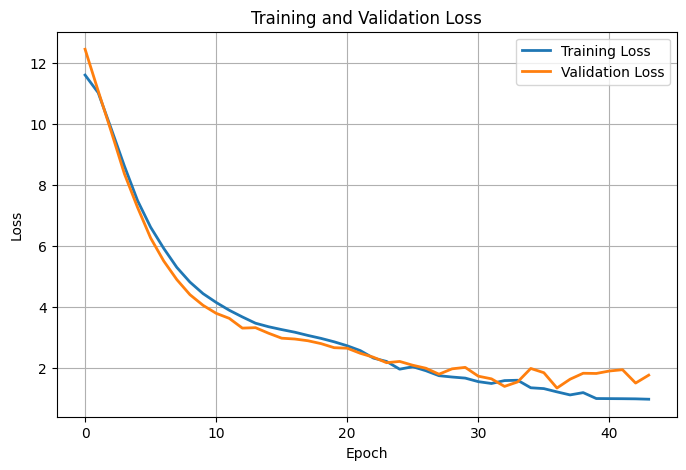

In [31]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(validation_losses, label='Validation Loss', linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

In [32]:
model.eval()

predictions = []
targets = []

with torch.no_grad():

    for x_batch, y_batch in test_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # [batch, window_size, 1]
        y_pred = model(x_batch)

        predictions.append(
            y_pred.cpu()
        )

        targets.append(
            y_batch.cpu()
        )

predictions = torch.cat(
    predictions,
    dim=0
)

targets = torch.cat(
    targets,
    dim=0
)

print("Predictions:", predictions.shape)
print("Targets:", targets.shape)

assert predictions.shape == targets.shape

Predictions: torch.Size([54, 1000, 1])
Targets: torch.Size([54, 1000, 1])


In [33]:
# Sono già espressi in kW
y_pred = predictions.numpy()
y_true = targets.numpy()

print("Predizioni:", y_pred.shape)
print("Target:", y_true.shape)

Predizioni: (54, 1000, 1)
Target: (54, 1000, 1)


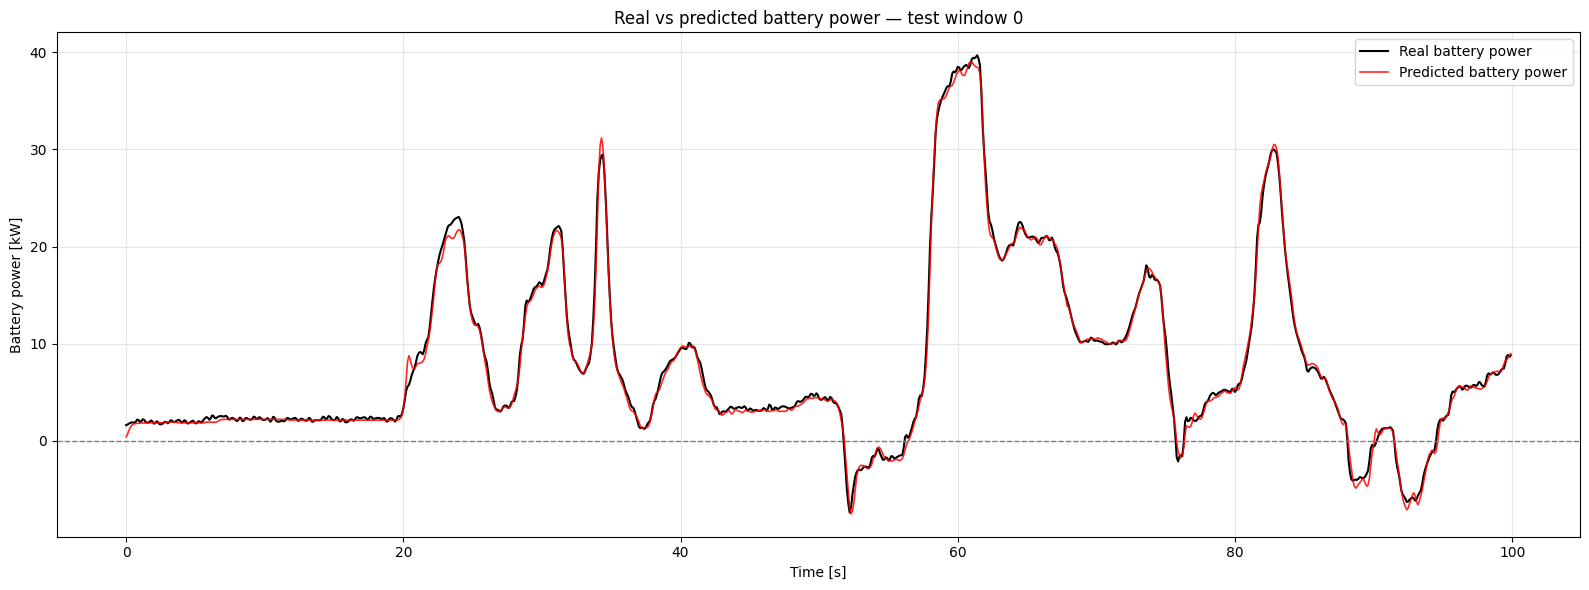

In [34]:
window_index = 0

real_power = y_true[
    window_index, :, 0
]

predicted_power = y_pred[
    window_index, :, 0
]

sampling_time = 0.1

time = (
    np.arange(len(real_power))
    * sampling_time
)

plt.figure(figsize=(16, 6))

plt.plot(
    time,
    real_power,
    label="Real battery power",
    color="black",
    linewidth=1.5
)

plt.plot(
    time,
    predicted_power,
    label="Predicted battery power",
    color="red",
    linewidth=1.2,
    alpha=0.85
)

plt.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Time [s]")
plt.ylabel("Battery power [kW]")

plt.title(
    f"Real vs predicted battery power — "
    f"test window {window_index}"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
y_true_all = targets.numpy().reshape(-1)
y_pred_all = predictions.numpy().reshape(-1)

print("Target complessivo:", y_true_all.shape)
print("Predizioni complessive:", y_pred_all.shape)

Target complessivo: (54000,)
Predizioni complessive: (54000,)


In [36]:
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# MAE
mae = mean_absolute_error(
    y_true_all,
    y_pred_all
)

# RMSE
rmse = np.sqrt(
    mean_squared_error(
        y_true_all,
        y_pred_all
    )
)

# R²
r2 = r2_score(
    y_true_all,
    y_pred_all
)

# MAPE filtrato per evitare divisioni per zero
threshold_kw = 1.0

valid_mask = (
    np.abs(y_true_all) >= threshold_kw
)

mape = (
    np.mean(
        np.abs(
            (
                y_true_all[valid_mask]
                - y_pred_all[valid_mask]
            )
            / y_true_all[valid_mask]
        )
    )
    * 100
)



print("Metriche sull'intero test set")
print(f"MAE:           {mae:.3f} kW")
print(f"RMSE:          {rmse:.3f} kW")
print(f"R²:            {r2:.4f}")
print(f"MAPE filtrato: {mape:.2f} %")

Metriche sull'intero test set
MAE:           0.875 kW
RMSE:          3.414 kW
R²:            0.9509
MAPE filtrato: 8.77 %


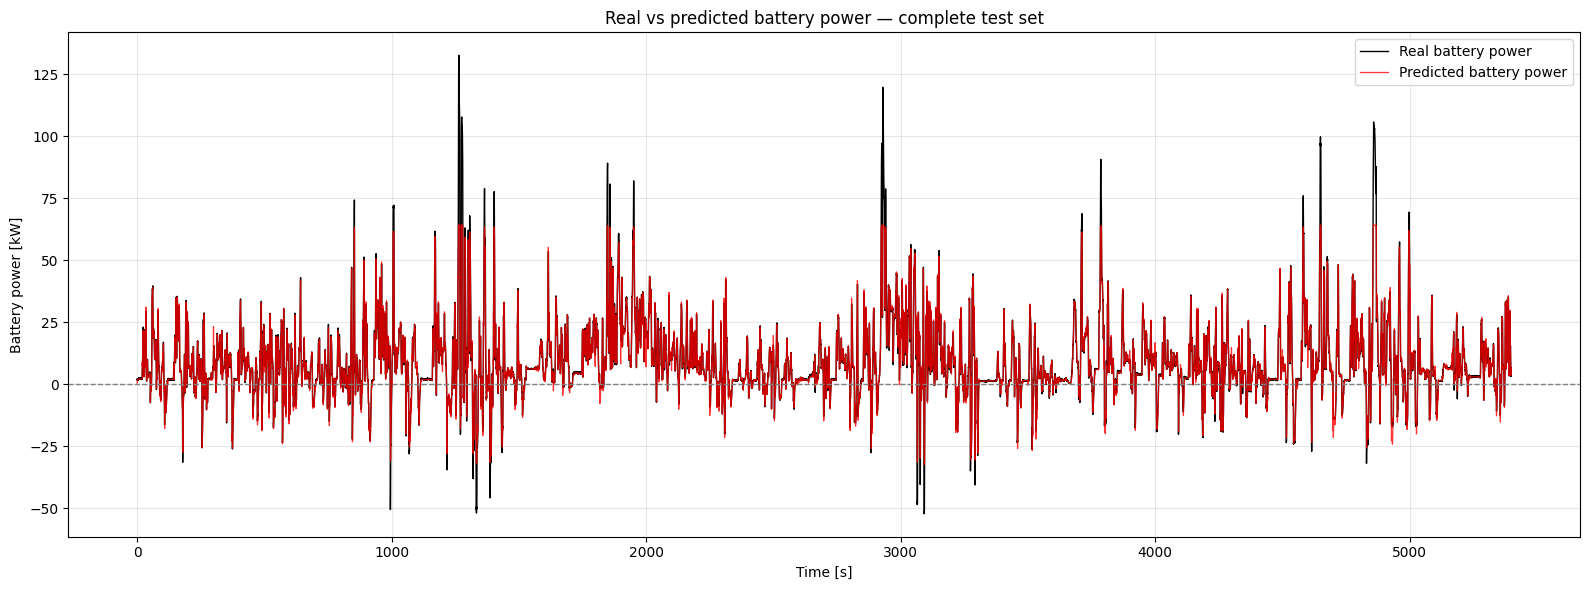

In [37]:
import matplotlib.pyplot as plt

sampling_time = 0.1

time_all = (
    np.arange(len(y_true_all))
    * sampling_time
)

plt.figure(figsize=(16, 6))

plt.plot(
    time_all,
    y_true_all,
    color="black",
    linewidth=1.0,
    label="Real battery power"
)

plt.plot(
    time_all,
    y_pred_all,
    color="red",
    linewidth=0.9,
    alpha=0.8,
    label="Predicted battery power"
)

plt.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Time [s]")
plt.ylabel("Battery power [kW]")
plt.title("Real vs predicted battery power — complete test set")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()